# Ni XRD Analysis: 2D Integration & Rietveld Refinement

This notebook demonstrates a complete XRD workflow for **metallic nickel (Ni)** using the **easyXRD** library:

1. **2D → 1D Integration** — pyFAI-based azimuthal integration of a raw detector TIFF image using a calibration file (`.poni`) and pixel mask (`.edf`).
2. **Phase Loading** — Load the Ni crystal structure from a local CIF file.
3. **GSAS-II Refinement Setup** — Transfer calibrated instrument parameters from a pre-refined `.gpx` file.
4. **Rietveld Refinement** — Sequential refinement of background, unit-cell parameters, instrument parameters, and atomic displacement parameters (Uiso).
5. **Results** — Final Rietveld plot with Rwp and GoF statistics.

---

### Files used

| File | Role |
|------|------|
| `Ni.tiff` | Raw 2D area-detector image |
| `_calibration.poni` | pyFAI detector geometry (λ = 0.1799 Å) |
| `_mask.edf` | Bad-pixel mask |
| `Ni.cif` | Nickel crystal structure |
| `_instrument_parameters.gpx` | Pre-refined GSAS-II instrument parameters |

---

**Reference notebooks:** `01_basic.ipynb`, `02_intermediate.ipynb` from the [easyXRD_examples](https://github.com/MehmetTopsakal/easyXRD_examples) repository.

## 1. Imports and Setup

In [1]:
import sys
import os
from pathlib import Path
import matplotlib.pyplot as plt
import fabio
import numpy as np

from easyxrd.core import exrd

%matplotlib inline
plt.rcParams["figure.constrained_layout.use"] = True

# Set working directory to the folder containing the data files
data_dir = Path(".").resolve()
os.chdir(data_dir)
print(f"Working directory: {data_dir}")

# Confirm all required files are present
required_files = [
    "Ni.tiff",
    "_calibration.poni",
    "_mask.edf",
    "Ni.cif",
    "_instrument_parameters.gpx",
]
for f in required_files:
    status = "✅" if Path(f).exists() else "❌ MISSING"
    print(f"  {status}  {f}")



Imported easyxrd with the following configuration:

easyxrd_scratch_path : /home/mt/.easyxrd_scratch
gsasii_lib_path : /home/mt/mpixi/.pixi/envs/default/lib/python3.14/site-packages/GSASII
mp_api_key : dHgNQRNYS..........
Working directory: /home/mt/repos/easyXRD_with_agents/00-Ni/Claude-Sonnet-4.6
  ✅  Ni.tiff
  ✅  _calibration.poni
  ✅  _mask.edf
  ✅  Ni.cif
  ✅  _instrument_parameters.gpx


## 2. Inspect the Raw 2D Detector Image

Before integration we display the raw TIFF and the corresponding mask.

Image shape : (3888, 3072)
Pixel dtype : float32
Intensity range: [-145.75100708007812, 6903.61279296875]


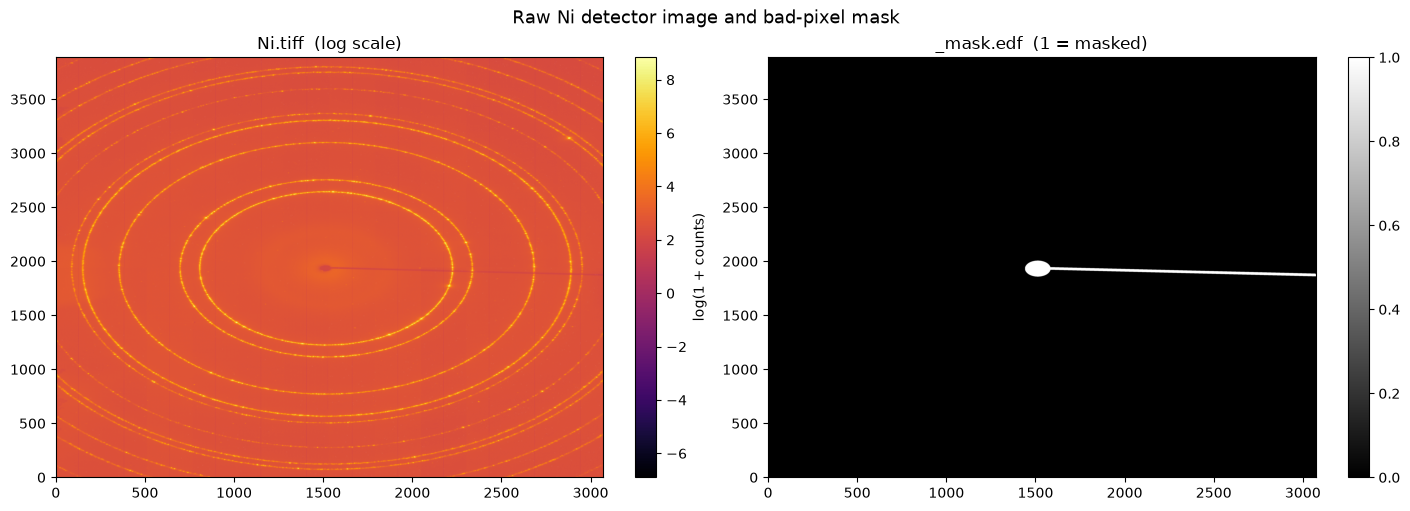

In [2]:
# Load and display the raw 2D image
img = fabio.open("Ni.tiff").data
print(f"Image shape : {img.shape}")
print(f"Pixel dtype : {img.dtype}")
print(f"Intensity range: [{img.min()}, {img.max()}]")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw image (log-scaled for visibility)
im0 = axes[0].imshow(
    np.log1p(img.astype(float)),
    origin="lower",
    cmap="inferno",
    aspect="auto",
)
axes[0].set_title("Ni.tiff  (log scale)")
plt.colorbar(im0, ax=axes[0], label="log(1 + counts)")

# Mask
mask = fabio.open("_mask.edf").data
im1 = axes[1].imshow(mask, origin="lower", cmap="gray", aspect="auto")
axes[1].set_title("_mask.edf  (1 = masked)")
plt.colorbar(im1, ax=axes[1])

plt.suptitle("Raw Ni detector image and bad-pixel mask", fontsize=13)
plt.show()

## 3. 2D → 1D Azimuthal Integration (pyFAI via easyXRD)

`exrd.load_xrd_data()` wraps pyFAI to perform the azimuthal integration in a single call.

Key parameters:
- **`from_tiff_file`** — raw detector image
- **`poni_file`** — detector geometry calibration (`_calibration.poni`; λ = 0.1799 Å)
- **`mask_file`** — bad-pixel mask (`_mask.edf`)

The result is a 1D profile in *q* (Å⁻¹) space stored in `sample.i1d`.

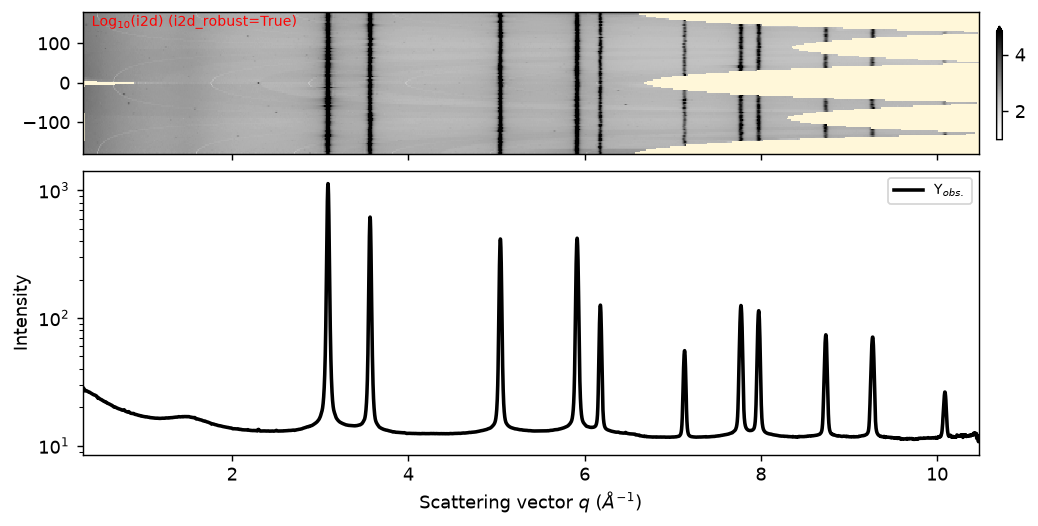

In [3]:
# Initialise easyXRD object
sample = exrd()

# Azimuthal integration — no q-range restriction yet so we see the full pattern
sample.load_xrd_data(
    from_tiff_file="Ni.tiff",
    poni_file="_calibration.poni",
    mask_file="_mask.edf",
)

# The figure shows:
#   Top panel  : 2D "cake" (azimuthally remapped image; yellow = masked pixels)
#   Bottom panel: 1D integrated profile I(q)

### 3.1 Choose the *q*-range for refinement

Based on the plot above we restrict the *q*-range to the useful signal region and re-integrate.

1D profile loaded.


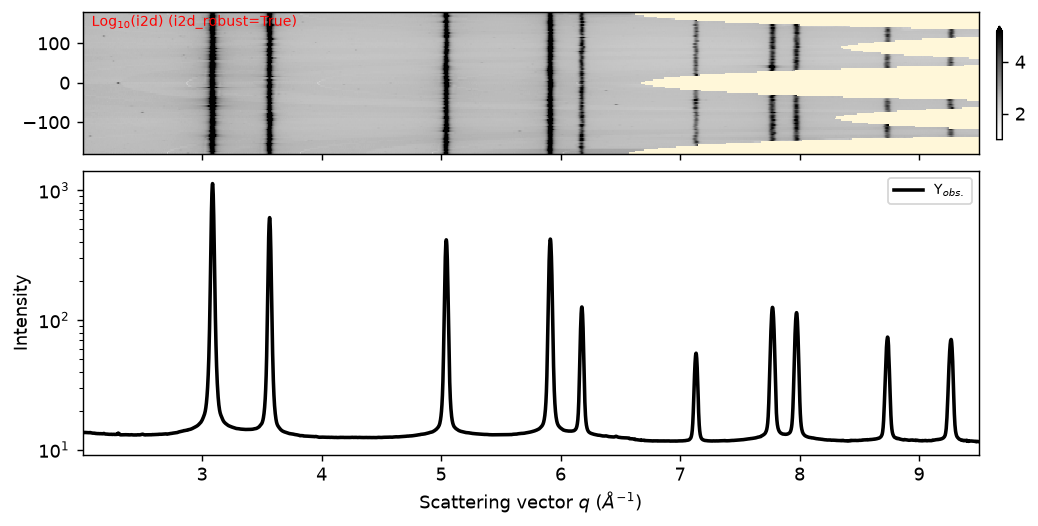

In [4]:
# Re-integrate with a focused q-range
# Ni (FCC, a ≈ 3.524 Å) produces Bragg peaks between ~2.5 and ~9 Å⁻¹ for λ = 0.1799 Å
sample = exrd()

sample.load_xrd_data(
    from_tiff_file="Ni.tiff",
    poni_file="_calibration.poni",
    mask_file="_mask.edf",
    radial_range=[2.0, 9.5],
)

print("1D profile loaded.")

## 4. Load Crystal Structure from CIF

We load the Ni FCC structure from the local `Ni.cif` file. easyXRD computes and overlays the expected Bragg peak positions.

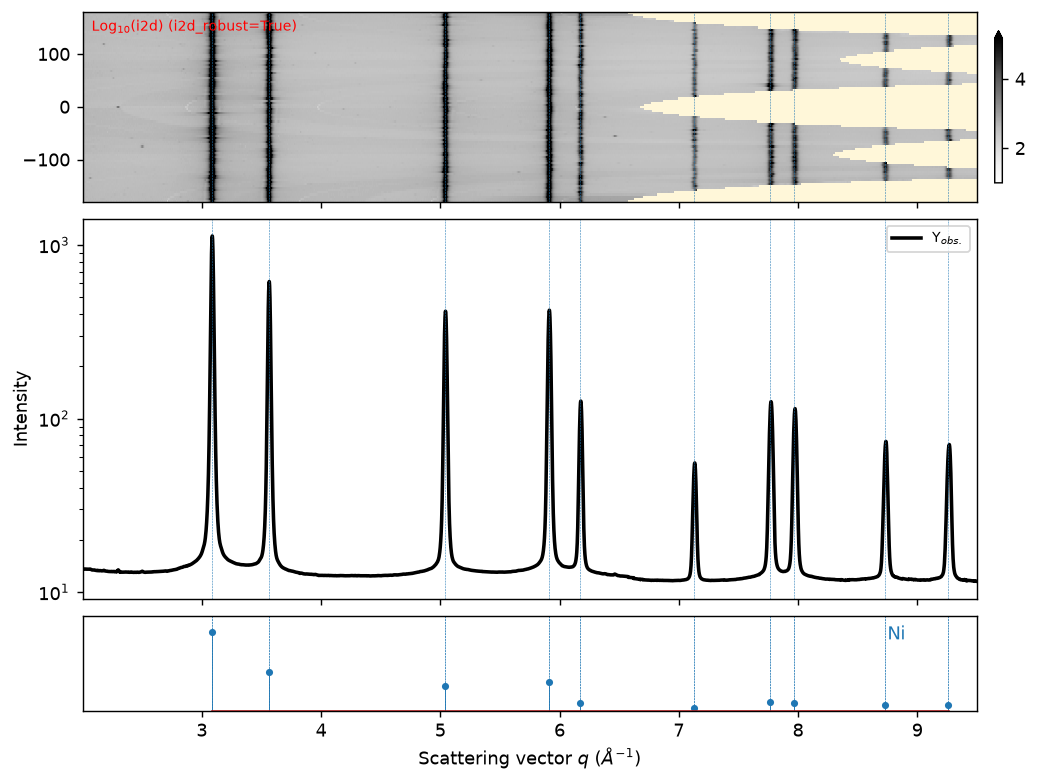

In [5]:
phases = [
    {"cif": "Ni.cif", "label": "Ni"},
]

sample.load_phases(phases, plot=True)

# The stem lines (blue ticks) mark expected Ni Bragg positions.
# Good agreement confirms the correct phase assignment.

## 5. Set Up GSAS-II Refiner with Pre-Calibrated Instrument Parameters

We load the instrument parameters directly from `_instrument_parameters.gpx` (already refined on a standard sample), avoiding the need to re-refine peak-shape parameters from scratch.


 ⏩--1st refinement with LeBail is completed. Rwp/GoF is 26.084/0.379 



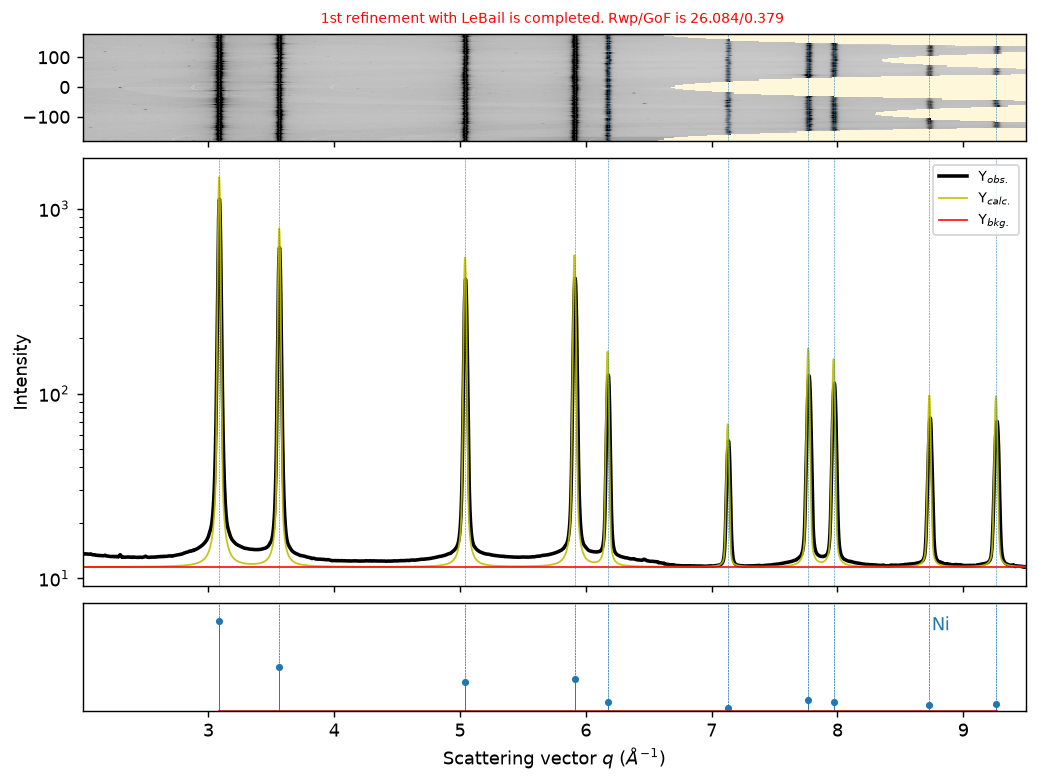

In [6]:
sample.setup_gsas2_refiner(
    plot=True,
    normalize=True,
    instprm_from_gpx="_instrument_parameters.gpx",
)

# The initial Rietveld profile is shown. Rwp and GoF will improve
# as we refine background, lattice, and atomic parameters.

## 6. Step-by-Step Rietveld Refinement

### 6.1 Background Refinement

Fit the diffuse background with a Chebyshev polynomial (default 10 coefficients).

 ✅--Background with 10 coeffs is refined. Rwp/GoF is now 22.005/0.320 (was 26.084(-15.64%)/0.379(-15.58%✨))


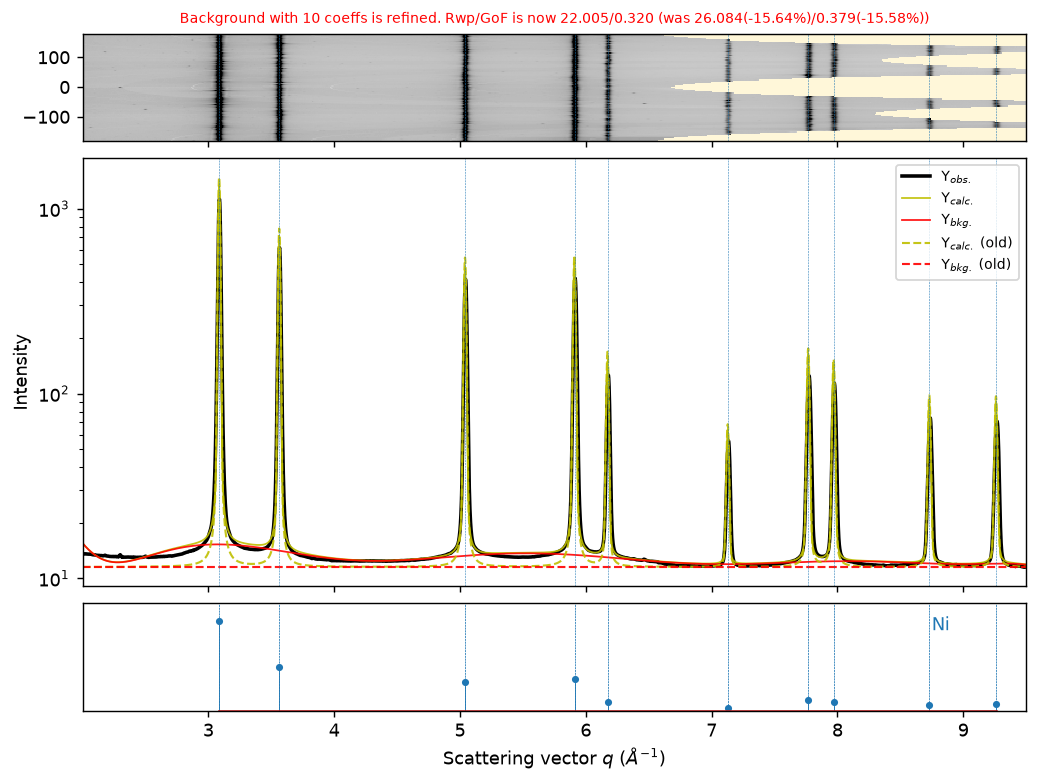

In [7]:
sample.refine_background(plot=True)

# Background fitting significantly reduces Rwp.

### 6.2 Unit-Cell Parameter Refinement

Refine the FCC lattice constant *a* of Ni.

 ✅--Cell parameters are refined. Rwp/GoF is now 13.677/0.199 (was 22.005(-37.85%)/0.320(-37.88%✨))


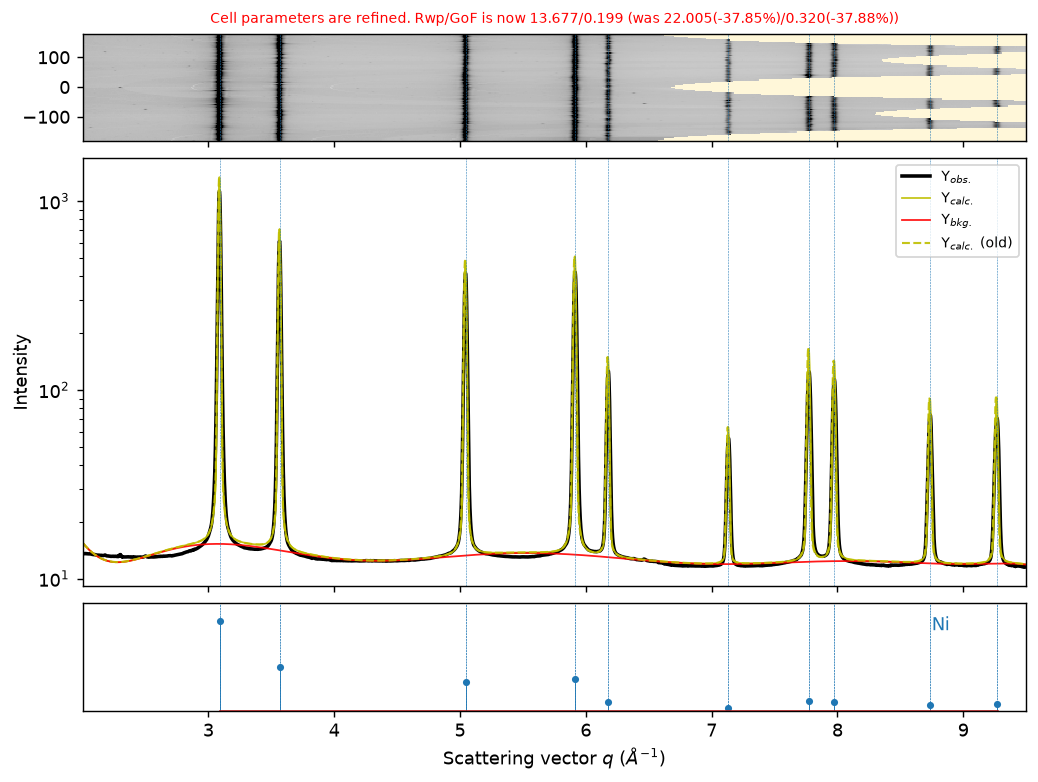

In [8]:
sample.refine_cell_parameters(plot=True)

# Adjusting the lattice constant aligns the calculated peak positions
# with the measured data, further reducing Rwp.

### 6.3 Instrument Parameter Refinement

Even though instrument parameters were loaded from the `.gpx`, small adjustments to the Gaussian broadening terms (U, V, W) and the zero offset can improve the fit.

 ✅--Instrument parameter ['U'] is refined. Rwp/GoF is now 7.661/0.111 (was 13.677(-43.99%)/0.199(-43.99%✨))
 ✅--Instrument parameter ['V'] is refined. Rwp/GoF is now 7.470/0.109 (was 7.661(-2.49%)/0.111(-2.49%))
 ✅--Instrument parameter ['W'] is refined. Rwp/GoF is now 7.348/0.107 (was 7.470(-1.64%)/0.109(-1.64%))
 ✅--Instrument parameter ['Zero'] is refined. Rwp/GoF is now 7.020/0.102 (was 7.348(-4.46%)/0.107(-4.46%))
Instrument parameter refinement complete.


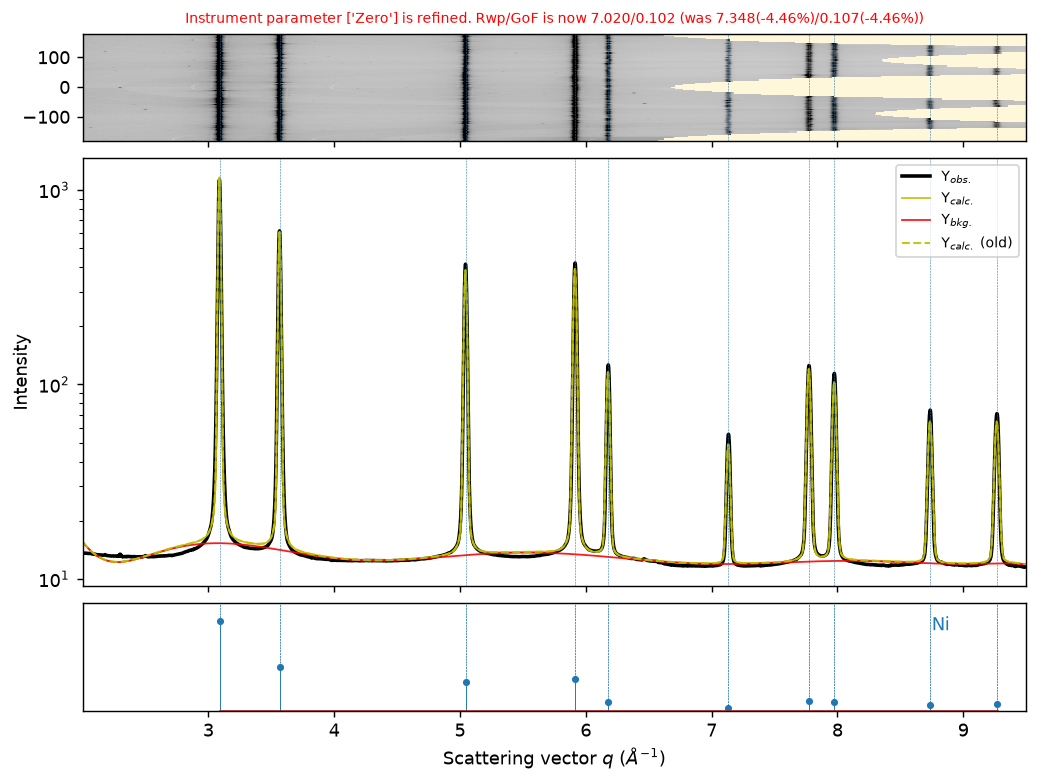

In [9]:
sample.refine_instrument_parameters(inst_pars_to_refine=["U"], plot=False)
sample.refine_instrument_parameters(inst_pars_to_refine=["V"], plot=False)
sample.refine_instrument_parameters(inst_pars_to_refine=["W"], plot=False)
sample.refine_instrument_parameters(inst_pars_to_refine=["Zero"], plot=True)

print("Instrument parameter refinement complete.")

### 6.4 Iterative Refinement Cycle

After updating the instrument parameters we refine the background and cell parameters again, then increase the background polynomial to 15 coefficients.

 ✅--Background with 5 coeffs is refined. Rwp/GoF is now 7.315/0.106 (was 7.020(4.20%)/0.102(4.22%❗))
 ✅--Background with 10 coeffs is refined. Rwp/GoF is now 6.779/0.099 (was 7.315(-7.32%)/0.106(-7.29%))
 ✅--Cell parameters are refined. Rwp/GoF is now 6.748/0.098 (was 6.779(-0.46%)/0.099(-0.52%❗))
 ✅--Background with 15 coeffs is refined. Rwp/GoF is now 6.587/0.096 (was 6.748(-2.38%)/0.098(-2.29%))
Iterative refinement cycle complete.


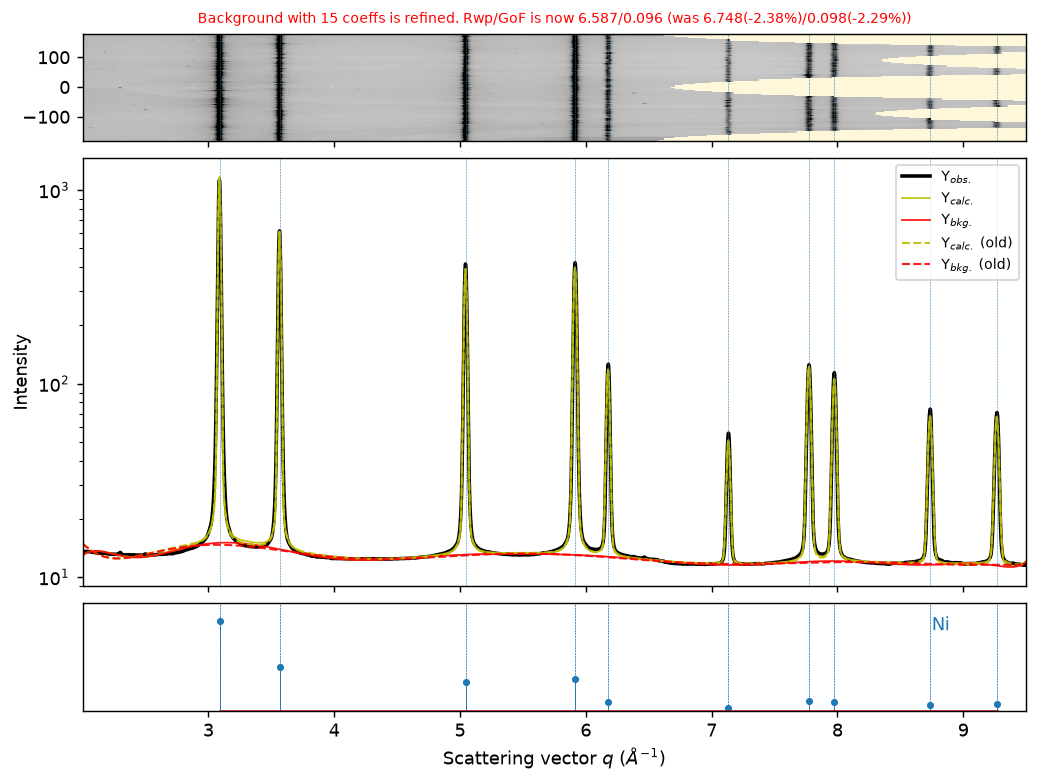

In [10]:
# Second pass: background → cell → background (more coefficients)
sample.refine_background(num_coeffs=5, plot=False)
sample.refine_background(num_coeffs=10, plot=False)
sample.refine_cell_parameters(plot=False)
sample.refine_background(num_coeffs=15, plot=True)

print("Iterative refinement cycle complete.")

### 6.5 Enable Full Rietveld (turn off Le Bail)

Up to this point we were doing Le Bail extraction (free peak intensities). Switching to Rietveld incorporates the atomic scattering factors and site occupancies.


 ✅--After setting LeBail refinement to False, Rwp/GoF is now 16.615/0.242 (was 6.587(152.23%)/0.096(151.98%❗))


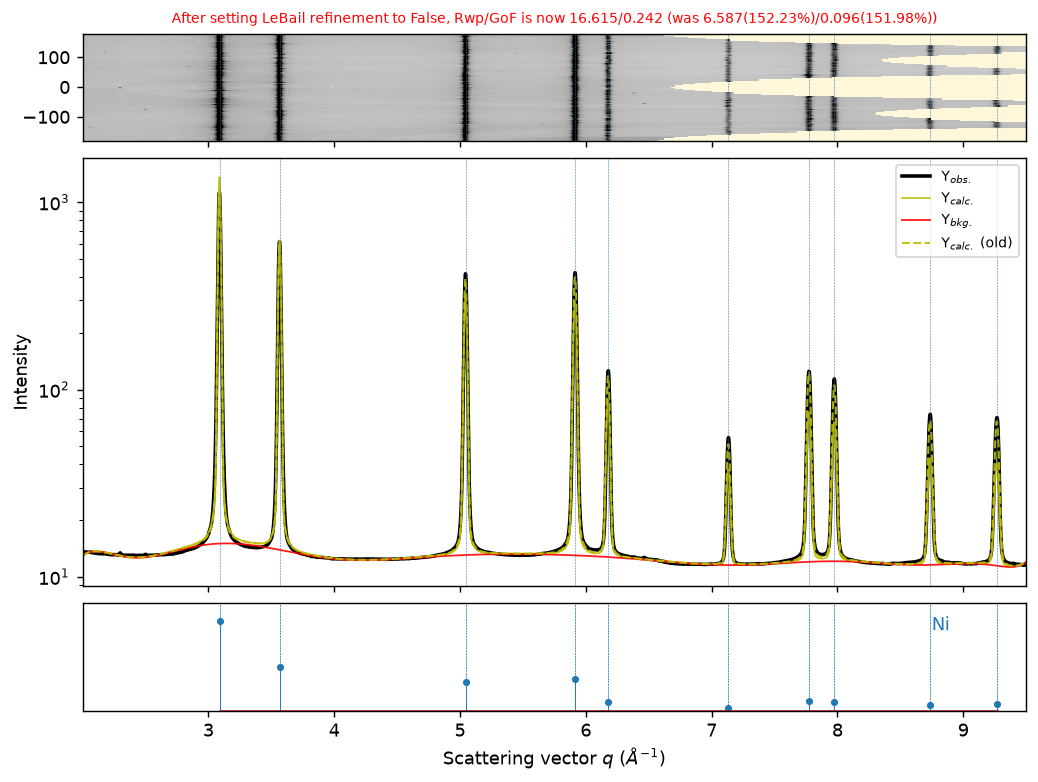

In [11]:
sample.set_LeBail(to=False, refine=True, plot=True)

# With atom positions now contributing to intensities, the fit may
# worsen slightly at first — we will improve it by refining Uiso.

### 6.6 Refine Atomic Displacement Parameter (Uiso)

Refine the isotropic thermal/displacement parameter for the Ni site.

 ✅--U property of Ni0 site of Ni phase is refined. Rwp/GoF is now 8.444/0.123 (was 16.615(-49.18%)/0.242(-49.17%✨))


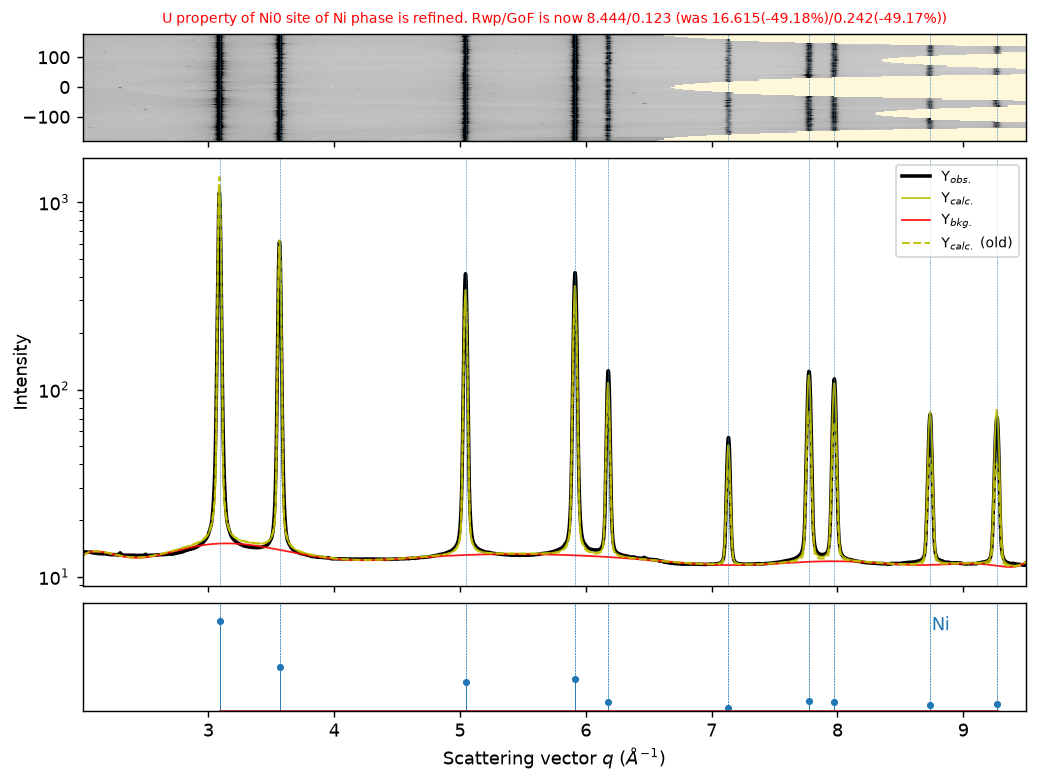

In [12]:
# Ni has a single Wyckoff site (4a). Refine its Uiso.
sample.refine_site_property(site_ind=0, refinement_flags="U", plot=True)

# Uiso refinement typically improves fit quality, especially at high q.

### 6.7 Final Refinement Pass

In [13]:
# Final simultaneous refinement of background and cell parameters
sample.refine_background(num_coeffs=15, plot=False)
sample.refine_cell_parameters(plot=False)

print("Final refinement pass complete.")

 ✅--Background with 15 coeffs is refined. Rwp/GoF is now 8.394/0.122 (was 8.444(-0.60%)/0.123(-0.50%❗))
 ✅--Cell parameters are refined. Rwp/GoF is now 8.387/0.122 (was 8.394(-0.08%)/0.122(-0.18%❗))
Final refinement pass complete.


## 7. Final Rietveld Plot and Results

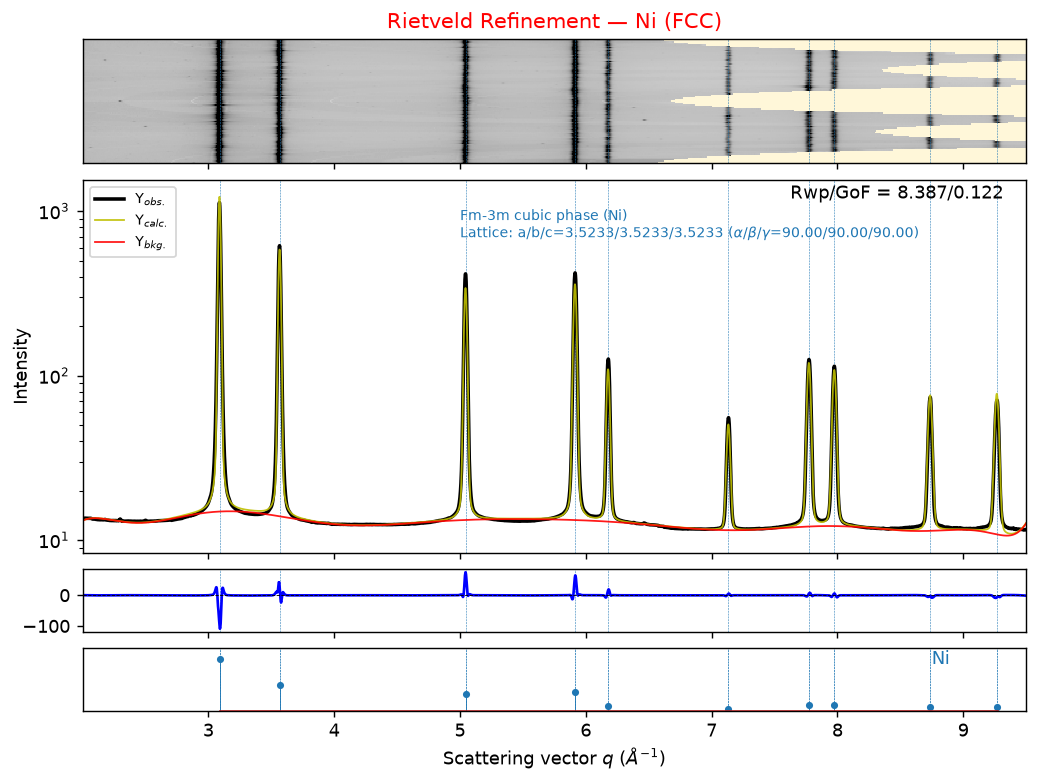

In [14]:
sample.plot(title="Rietveld Refinement — Ni (FCC)")

### 7.1 Summary of Refined Parameters

In [15]:
# Print the current refinement statistics stored inside the easyXRD object
try:
    print("=== Refinement Summary ===")
    # Retrieve GSAS-II results
    results = sample.gsas2_results
    for k, v in results.items():
        print(f"  {k}: {v}")
except AttributeError:
    # Fallback: print whatever the sample object exposes
    print(repr(sample))

=== Refinement Summary ===


## 8. Export GSAS-II Project File

In [16]:
# Save the refined GSAS-II project so it can be opened in the GSAS-II GUI
sample.export_gpx_to("Ni_refined.gpx")
print("Saved: Ni_refined.gpx")

Saved: Ni_refined.gpx


## 9. All-in-One Summary Workflow

The cell below runs the entire pipeline in one shot (useful for automation).


 ⏩--1st refinement with LeBail is completed. Rwp/GoF is 26.084/0.379 

 ✅--Background with 10 coeffs is refined. Rwp/GoF is now 22.005/0.320 (was 26.084(-15.64%)/0.379(-15.58%✨))
 ✅--Cell parameters are refined. Rwp/GoF is now 13.677/0.199 (was 22.005(-37.85%)/0.320(-37.88%✨))
 ✅--Instrument parameter ['U'] is refined. Rwp/GoF is now 7.661/0.111 (was 13.677(-43.99%)/0.199(-43.99%✨))
 ✅--Instrument parameter ['V'] is refined. Rwp/GoF is now 7.470/0.109 (was 7.661(-2.49%)/0.111(-2.49%))
 ✅--Instrument parameter ['W'] is refined. Rwp/GoF is now 7.348/0.107 (was 7.470(-1.64%)/0.109(-1.64%))
 ✅--Instrument parameter ['Zero'] is refined. Rwp/GoF is now 7.020/0.102 (was 7.348(-4.46%)/0.107(-4.46%))
 ✅--Background with 15 coeffs is refined. Rwp/GoF is now 6.619/0.096 (was 7.020(-5.71%)/0.102(-5.63%))
 ✅--Cell parameters are refined. Rwp/GoF is now 6.584/0.096 (was 6.619(-0.53%)/0.096(-0.62%❗))

 ✅--After setting LeBail refinement to False, Rwp/GoF is now 16.604/0.241 (was 6.584(152.19%)/0.096

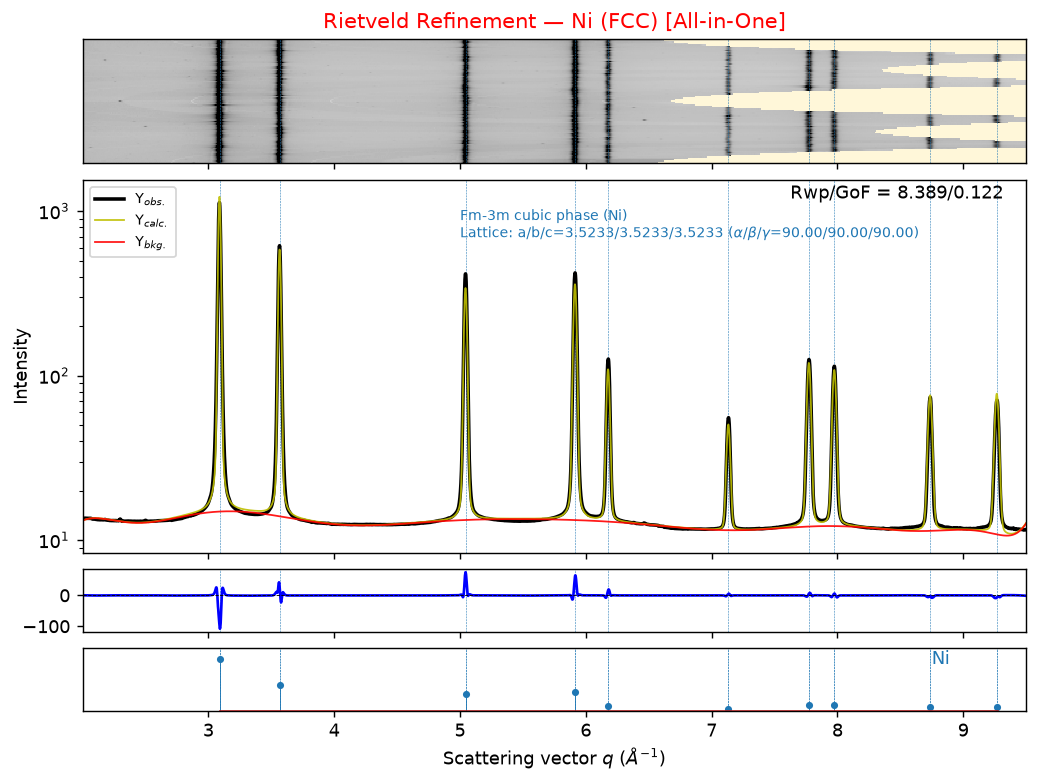

In [17]:
# -------------------------------------------------------
# ALL-IN-ONE WORKFLOW — Ni 2D integration + Rietveld
# -------------------------------------------------------
s = exrd()

# 1. Integrate 2D TIFF → 1D profile
s.load_xrd_data(
    from_tiff_file="Ni.tiff",
    poni_file="_calibration.poni",
    mask_file="_mask.edf",
    radial_range=[2.0, 9.5],
    plot=False,
)

# 2. Load crystal structure
s.load_phases([{"cif": "Ni.cif", "label": "Ni"}], plot=False)

# 3. Setup GSAS-II with pre-calibrated instrument parameters
s.setup_gsas2_refiner(
    plot=False,
    normalize=True,
    instprm_from_gpx="_instrument_parameters.gpx",
)

# 4. Le Bail phase: background → cell → instrument → background
s.refine_background(plot=False)
s.refine_cell_parameters(plot=False)
s.refine_instrument_parameters(inst_pars_to_refine=["U"], plot=False)
s.refine_instrument_parameters(inst_pars_to_refine=["V"], plot=False)
s.refine_instrument_parameters(inst_pars_to_refine=["W"], plot=False)
s.refine_instrument_parameters(inst_pars_to_refine=["Zero"], plot=False)
s.refine_background(num_coeffs=15, plot=False)
s.refine_cell_parameters(plot=False)

# 5. Switch to full Rietveld
s.set_LeBail(to=False, refine=True, plot=False)

# 6. Refine Uiso for Ni site
s.refine_site_property(site_ind=0, refinement_flags="U", plot=False)

# 7. Final pass
s.refine_background(num_coeffs=15, plot=False)
s.refine_cell_parameters(plot=False)

# 8. Display results
s.plot(title="Rietveld Refinement — Ni (FCC) [All-in-One]")

# 9. Export
s.export_gpx_to("Ni_refined_aio.gpx")
print("All-in-one workflow complete. Saved: Ni_refined_aio.gpx")

---

## Notes

- **Wavelength**: λ = 0.1799 Å (from `_calibration.poni`).
- **Detector**: Dexela 2923 (75 µm pixels).
- **Standard**: The `_instrument_parameters.gpx` was refined on a NIST standard to fix peak-shape parameters before analyzing the Ni sample.
- **Rietveld vs Le Bail**: Le Bail extraction (the default in easyXRD until `set_LeBail(to=False)` is called) freely refines peak intensities without structural constraints. Full Rietveld uses atomic scattering factors and site multiplicities, yielding physically meaningful intensities.
- **Ni reference**: FCC, space group *Fm*3̄*m*, a ≈ 3.5238 Å (JCPDS 04-0850).